# 02b — Process Performance Map with Resource sub-nodes (Camargo DomesticDeclarations)

Experimental variant of `02_process_performance_map.ipynb`. Each **activity** is rendered as a graphviz cluster with:

- one **hub** node (the activity itself), color ∝ overall per-activity next-activity accuracy
- one **resource sub-node** per (activity, resource) pair seen in the log, color ∝ next-activity accuracy at that *(activity, resource)* gateway

Each transition `(src_act, src_res) → (tgt_act, tgt_res)` produces **two edges**:

1. Solid colored edge: `src_act/src_res` sub-node → `tgt_act` hub. Color = next-activity prediction accuracy at the source state. This captures whether the model gets the activity right when leaving from a specific resource.
2. Dashed gray edge: `tgt_act` hub → `tgt_act/tgt_res` sub-node. Just shows the resource distribution within the target activity (the Camargo `FullShared_Join_LSTM` doesn’t predict resource, so we can’t score it).

So the visual flow `Approved/STAFF → Final Approved (hub) → Final Approved/SYSTEM` corresponds to the actual transition `(Approved, STAFF) → (Final Approved, SYSTEM)`. The colour of the first arrow tells you whether the model would have predicted `Final Approved` from `(Approved, STAFF)`.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.DOMESTIC_DECLARATIONS

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)

# Cat-feature index lookup. cat_indices=(0, 1) for DomesticDeclarations means
# Activity is at dataset.all_categories[0][0] and Resource at [0][1].
ACT_IDX = SPEC.cat_indices[0]
RES_IDX = SPEC.cat_indices[1]
res_meta = dataset.all_categories[0][RES_IDX]
res_idx_to_name = {v: k for k, v in res_meta[2].items()}

print(f'Loaded Camargo {SPEC.name} | window={window} | activities={predictor.n_classes - 1} | '
      f'resources={len(res_idx_to_name)} ({list(res_idx_to_name.values())})')

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]
Embeddings:  ModuleList(
  (0): Embedding(10, 6)
  (1): Embedding(4, 3)
)
Total embedding feature size:  9
Number of numerical features:  1
Input feature size (shared LSTM, cat-only):  10
Cells hidden size:  50
Number of LSTM layer:  1


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


RuntimeError: Error(s) in loading state_dict for SharedCat_LSTM:
	size mismatch for lstm_act.weight_ih_l0: copying a param with shape torch.Size([200, 50]) from checkpoint, the shape in current model is torch.Size([200, 51]).

In [ ]:
# Collect predictions and augment each record with current & actual-next resource.
# Resource is read from the dataset directly (Camargo doesn't predict it).
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)

# Build a per-case lookup so we can grab the resource at any position.
cases = {}
for i in range(len(dataset)):
    cat_t, _, cid = dataset[i]
    L = int((cat_t[ACT_IDX] != 0).sum().item())
    if cid not in cases or L > cases[cid][1]:
        cases[cid] = (i, L)

eos_idx = predictor.eos_idx

for r in records:
    cid = r['case_id']
    plen = r['prefix_length']
    ds_idx, _ = cases[cid]
    cat_t, _, _ = dataset[ds_idx]
    full_a = cat_t[ACT_IDX].tolist()
    full_r = cat_t[RES_IDX].tolist()
    nz = [i for i, a in enumerate(full_a) if a != 0]
    start = nz[0]

    # current resource = resource at the gateway event (last in prefix)
    r['current_resource'] = res_idx_to_name.get(full_r[start + plen - 1], '<unk>')

    # actual next resource = resource at position prefix_length, OR EOS at case end
    last_useful = len([a for a in full_a[start:] if a != 0])
    while last_useful > 0 and full_a[start + last_useful - 1] == eos_idx:
        last_useful -= 1
    if plen < last_useful:
        r['actual_next_resource'] = res_idx_to_name.get(full_r[start + plen], '<unk>')
    else:
        r['actual_next_resource'] = 'EOS'

print(f'Augmented {len(records)} records with resource info.')
print(f'Distinct (current_activity, current_resource): '
      f'{len({(r["current_activity"], r["current_resource"]) for r in records})}')
print(f'Distinct (actual_next_activity, actual_next_resource): '
      f'{len({(r["actual_next_activity"], r["actual_next_resource"]) for r in records})}')

Augmented 11271 records with resource info.
Distinct (current_activity, current_resource): 7
Distinct (actual_next_activity, actual_next_resource): 7


In [ ]:
import pandas as pd
from collections import defaultdict

# Per (current_activity, current_resource) accuracy on next-activity prediction.
src_state_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['current_resource'])
    src_state_stats[key]['total'] += 1
    src_state_stats[key]['correct'] += int(r['correct'])

# Edge 1: (src_act, src_res, tgt_act) -> {total, correct}.
# Counts the actual transitions out of the (src_act, src_res) node toward
# each target activity, plus how many were predicted correctly.
edge1_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['current_resource'], r['actual_next_activity'])
    edge1_stats[key]['total'] += 1
    edge1_stats[key]['correct'] += int(r['correct'])

# Edge 2: (tgt_act, tgt_res) landing counts -- aggregated regardless of predecessor.
edge2_stats = defaultdict(int)
for r in records:
    edge2_stats[(r['actual_next_activity'], r['actual_next_resource'])] += 1

# Per-activity hub stats (for hub colour).
act_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    act_stats[r['current_activity']]['total'] += 1
    act_stats[r['current_activity']]['correct'] += int(r['correct'])

# Per (activity, resource) breakdown table
rows = []
for (act, res), s in src_state_stats.items():
    rows.append({
        'activity': act, 'resource': res,
        'correct': s['correct'], 'total': s['total'],
        'accuracy': s['correct'] / s['total'] if s['total'] else 0.0,
    })
state_df = pd.DataFrame(rows).sort_values(['activity', 'total'], ascending=[True, False])
print(f'{len(state_df)} distinct (activity, resource) gateway states\n')
with pd.option_context('display.max_rows', None):
    display(state_df)

7 distinct (activity, resource) gateway states



,activity,resource,correct,total,accuracy
1,APPROVED,STAFF MEMBER,724,2370,0.305485
2,FINAL_APPROVED,STAFF MEMBER,1998,2019,0.989599
4,Payment Handled,SYSTEM,1999,1999,1.000000
5,REJECTED,STAFF MEMBER,298,561,0.531194
3,Request Payment,SYSTEM,1997,1998,0.999499
6,SAVED,STAFF MEMBER,0,29,0.000000
0,SUBMITTED,STAFF MEMBER,193,2295,0.084096


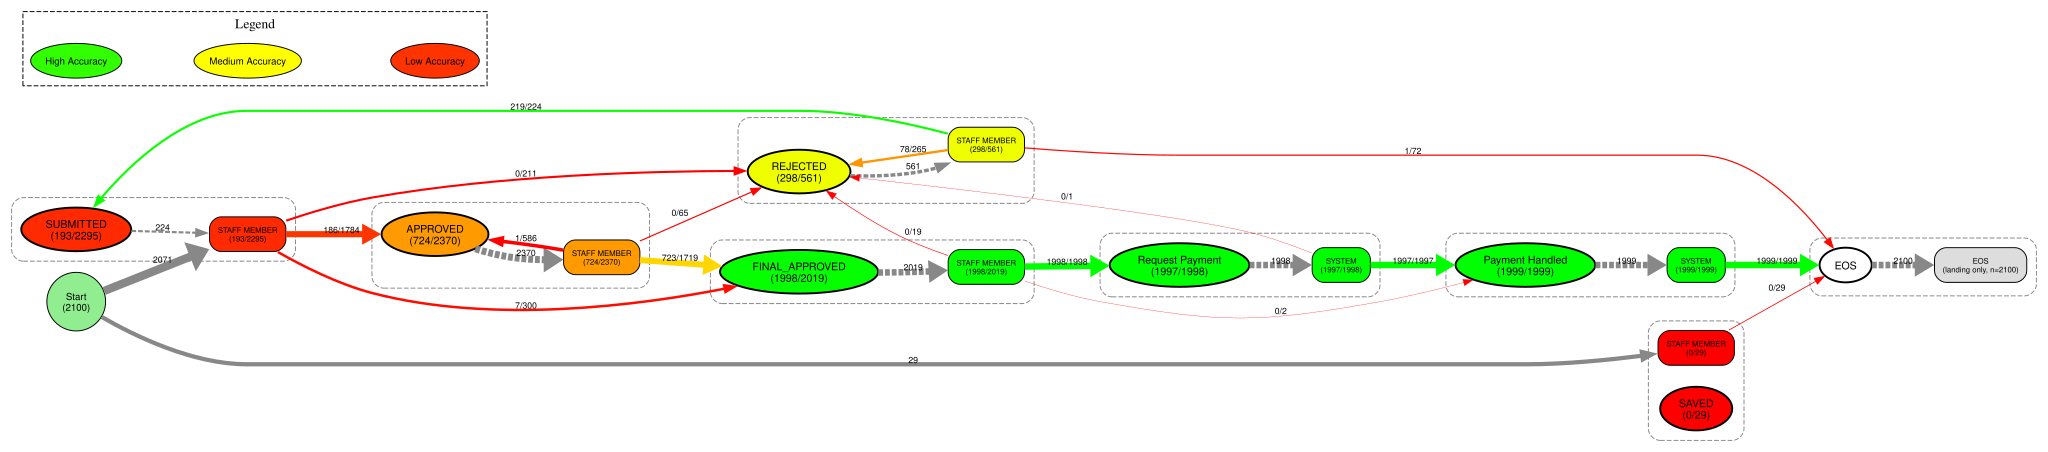

In [ ]:
import graphviz
import math

# Filtering knobs -- raise to declutter on busier datasets.
MIN_EDGE_COUNT = 0          # hide first-edges (src_state -> tgt_hub) below this
MIN_RESOURCE_NODE_COUNT = 0 # hide (act, res) sub-nodes seen fewer times


def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) -- matches the henryk PPM gradient."""
    if accuracy < 0.5:
        r = 255; g = int(255 * (accuracy * 2)); b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2)); g = 255; b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


def _safe(s: str) -> str:
    return ''.join(ch if (ch.isalnum() or ch == '_') else '_' for ch in s)

def hub_id(act: str) -> str:
    return f'hub__{_safe(act)}'

def res_id(act: str, res: str) -> str:
    return f'res__{_safe(act)}__{_safe(res)}'


# Activities that appear anywhere as a source or target.
all_activities = set()
for (a, _r), _s in src_state_stats.items():
    all_activities.add(a)
for (_a, _r, t), _s in edge1_stats.items():
    all_activities.add(t)
for (a, _r), _c in edge2_stats.items():
    all_activities.add(a)

# (activity, resource) sub-nodes to render: union of source-side and target-side states.
state_counts = defaultdict(int)
for (a, r), s in src_state_stats.items():
    state_counts[(a, r)] += s['total']
for (a, r), c in edge2_stats.items():
    state_counts[(a, r)] += c

dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} -- hierarchical PPM (resource-aware)')
dot.attr(rankdir='LR', compound='true', nodesep='0.3', ranksep='0.6')
dot.attr('node', fontsize='10', fontname='Helvetica')
dot.attr('edge', fontsize='9', fontname='Helvetica')

# One cluster per activity, containing a hub + per-resource sub-nodes.
for act in sorted(all_activities):
    s_act = act_stats[act]
    if s_act['total'] > 0:
        acc = s_act['correct'] / s_act['total']
        hub_fill = get_color_for_accuracy(acc)
        hub_label = f'{act}\n({s_act["correct"]}/{s_act["total"]})'
    else:
        hub_fill = 'white'
        hub_label = act

    with dot.subgraph(name=f'cluster_{_safe(act)}') as c:
        c.attr(label='', style='rounded,dashed', color='#888888', margin='10')
        c.node(hub_id(act), label=hub_label, shape='ellipse',
               style='filled,bold', fillcolor=hub_fill, fontsize='11')

        # Resource sub-nodes inside this cluster.
        res_in_act = [(r, n) for (a, r), n in state_counts.items()
                      if a == act and n >= MIN_RESOURCE_NODE_COUNT]
        for r, n in sorted(res_in_act, key=lambda x: -x[1]):
            sst = src_state_stats.get((act, r))
            if sst and sst['total'] > 0:
                racc = sst['correct'] / sst['total']
                rfill = get_color_for_accuracy(racc)
                rlabel = f'{r}\n({sst["correct"]}/{sst["total"]})'
            else:
                # No source-side rows: this (act, res) is only ever a landing state.
                rfill = '#dddddd'
                rlabel = f'{r}\n(landing only, n={n})'
            c.node(res_id(act, r), label=rlabel, shape='box',
                   style='rounded,filled', fillcolor=rfill, fontsize='8')

# Synthetic Start node: number of cases starting at each (act, res).
start_state_counts = defaultdict(int)
for r in records:
    if r['prefix_length'] == 1:
        start_state_counts[(r['current_activity'], r['current_resource'])] += 1
total_starts = sum(start_state_counts.values())
if total_starts:
    dot.node('__START__', label=f'Start\n({total_starts})',
             shape='circle', style='filled', fillcolor='#90EE90')
    for (a, r), n in start_state_counts.items():
        if n >= MIN_EDGE_COUNT:
            dot.edge('__START__', res_id(a, r), label=str(n), color='#888888',
                     penwidth=str(1 + math.log1p(n)),
                     weight=str(int(math.log1p(n) * 10)))

# Edge 1 -- solid colored: (src_act, src_res) sub-node -> tgt_act hub.
for (src_a, src_r, tgt_a), s in edge1_stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f'{s["correct"]}/{s["total"]}'
    dot.edge(res_id(src_a, src_r), hub_id(tgt_a),
             label=label, color=color,
             penwidth=str(max(0.3, math.sqrt(s['total']) * 0.15)),
             weight=str(int(math.log1p(s['total']) * 10)))

# Edge 2 -- dashed gray: tgt hub -> (tgt_act, tgt_res). Resource distribution
# within each landing activity. Not coloured (model doesn't predict resource).
for (tgt_a, tgt_r), n in edge2_stats.items():
    if n < MIN_EDGE_COUNT:
        continue
    if (tgt_a, tgt_r) not in state_counts:
        continue
    dot.edge(hub_id(tgt_a), res_id(tgt_a, tgt_r),
             label=str(n), color='#888888', style='dashed',
             penwidth=str(max(0.3, math.sqrt(n) * 0.15)),
             weight=str(int(math.log1p(n) * 10)))

# Legend
with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', shape='ellipse', style='filled',
                fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', shape='ellipse', style='filled',
                fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', shape='ellipse', style='filled',
                fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [ ]:
# Per (activity, resource) accuracy ranking -- shows whether the model is
# better at some resources than others within the same activity.
print('Per (activity, resource) next-activity accuracy:')
for (act, res), s in sorted(src_state_stats.items(),
                            key=lambda x: (x[0][0], -x[1]['total'])):
    acc = s['correct'] / s['total'] if s['total'] else 0.0
    print(f"  {act:<25s} {res:<15s}  {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per (activity, resource) next-activity accuracy:
  APPROVED                  STAFF MEMBER       724/2370    30.5%
  FINAL_APPROVED            STAFF MEMBER      1998/2019    99.0%
  Payment Handled           SYSTEM            1999/1999   100.0%
  REJECTED                  STAFF MEMBER       298/561     53.1%
  Request Payment           SYSTEM            1997/1998    99.9%
  SAVED                     STAFF MEMBER         0/29       0.0%
  SUBMITTED                 STAFF MEMBER       193/2295     8.4%
